In [1]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from jetnet.utils import EtaPhiPtE_to_cartesian, cartesian_to_EtaPhiPtE

RANDOM_SEED = 42

/Users/arjunsharma/development/s25-fermilab-research/src/venv/lib/python3.10/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


## Model investigation

In [2]:
OUTPUT_DIR = "downloaded_output"
# OUTPUT_DIR = "out/2025-07-21_00:41:05.284314"

### Did weights update?

In [3]:
model_info = torch.load(f"{OUTPUT_DIR}/models/final_model.pth", map_location=torch.device('cpu'))

In [4]:
from models.ConditionalLEFlowMatching import JetFMGenerator

n_layers = 1 + int(list(model_info.keys())[-37].split("layers.")[-1].split(".")[0])
model = JetFMGenerator(n_layers=n_layers)
model.load_state_dict(model_info)

<All keys matched successfully>

In [5]:
initial_model = JetFMGenerator(n_layers=n_layers)
initial_model.load_state_dict(
    torch.load(f"{OUTPUT_DIR}/models/model_initial.pth", map_location=torch.device('cpu'))
)

<All keys matched successfully>

In [6]:
def compare_models(model_1, model_2):
    models_differ = 0
    for key_item_1, key_item_2 in zip(model_1.state_dict().items(), model_2.state_dict().items()):
        if torch.equal(key_item_1[1], key_item_2[1]):
            # print('Models match at', key_item_1[0])
            pass
        else:
            models_differ += 1
            if (key_item_1[0] == key_item_2[0]):
                print('Mismatch found at', key_item_1[0])
            else:
                raise Exception
    if models_differ == 0:
        print('Models match perfectly! :)')

compare_models(model, initial_model)

Mismatch found at time_embedding.fc1.weight
Mismatch found at time_embedding.fc1.bias
Mismatch found at time_embedding.fc2.weight
Mismatch found at time_embedding.fc2.bias
Mismatch found at initial_global.network.0.weight
Mismatch found at initial_global.network.0.bias
Mismatch found at initial_global.network.1.weight
Mismatch found at initial_global.network.1.bias
Mismatch found at initial_global.network.1.running_mean
Mismatch found at initial_global.network.1.running_var
Mismatch found at initial_global.network.1.num_batches_tracked
Mismatch found at initial_global.network.3.weight
Mismatch found at initial_global.network.3.bias
Mismatch found at initial_global.network.4.weight
Mismatch found at initial_global.network.4.bias
Mismatch found at initial_global.network.4.running_mean
Mismatch found at initial_global.network.4.running_var
Mismatch found at initial_global.network.4.num_batches_tracked
Mismatch found at initial_global.network.6.weight
Mismatch found at initial_global.netwo

## Load test data

In [7]:
with open(f"{OUTPUT_DIR}/gen/x_test.pkl", "rb") as f:
    X_test = pickle.load(f)

In [8]:
jet_eta = (X_test[:][1][:, 0]).unsqueeze(1)
jet_phi_vals = (2 * torch.pi) * torch.rand(len(X_test)).unsqueeze(1)
jet_pt_ec = X_test[:][1][:, 1:3]
jet_features = torch.concat([jet_eta, jet_phi_vals, jet_pt_ec], dim=-1)
eta_rel, phi_rel, pt_rel = torch.unbind(X_test[:][0][:, :, :3], axis=-1)
Eta, Phi, Pt, _ = torch.unbind(jet_features, axis=-1)

pt = pt_rel * Pt.unsqueeze(1)
eta = eta_rel + Eta.unsqueeze(1)
phi = phi_rel + Phi.unsqueeze(1)
p0 = pt * torch.cosh(eta)

test_features_absolute = torch.stack([eta, phi, pt, p0], dim=-1)

Text(0.5, 0.98, 'Test Features Distribution')

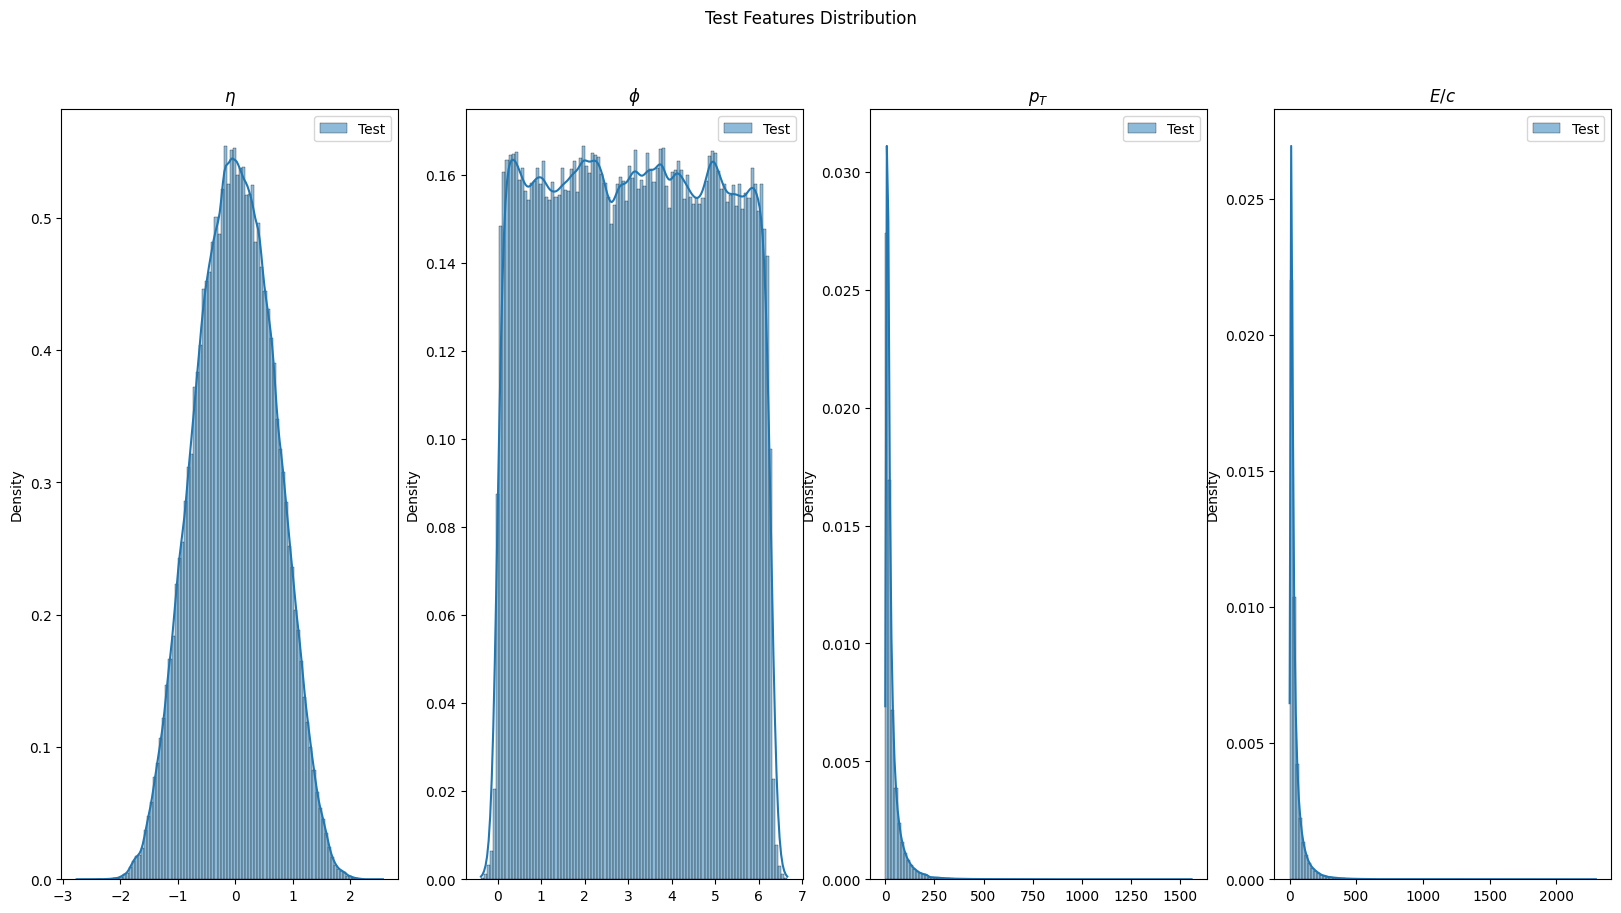

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features = [r"$\eta$", r"$\phi$", r"$p_T$", r"$E/c$"]
for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        test_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Test"
    )
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Test Features Distribution")

In [10]:
test_features_cartesian = EtaPhiPtE_to_cartesian(test_features_absolute)

## Load output

In [11]:
scale_factor = open(f"{OUTPUT_DIR}/logs/final_scale.txt", "r").readline().strip()
scale_factor = float(scale_factor)
scale_factor

42.2790412902832

In [12]:
gen_features_cartesian = open(f"{OUTPUT_DIR}/gen/samples_cartesian.pt", "rb")
gen_features_cartesian = torch.load(gen_features_cartesian, map_location=torch.device('cpu'))

torch.Size([500, 30, 4])


Text(0.5, 0.98, 'Generated Features Distribution')

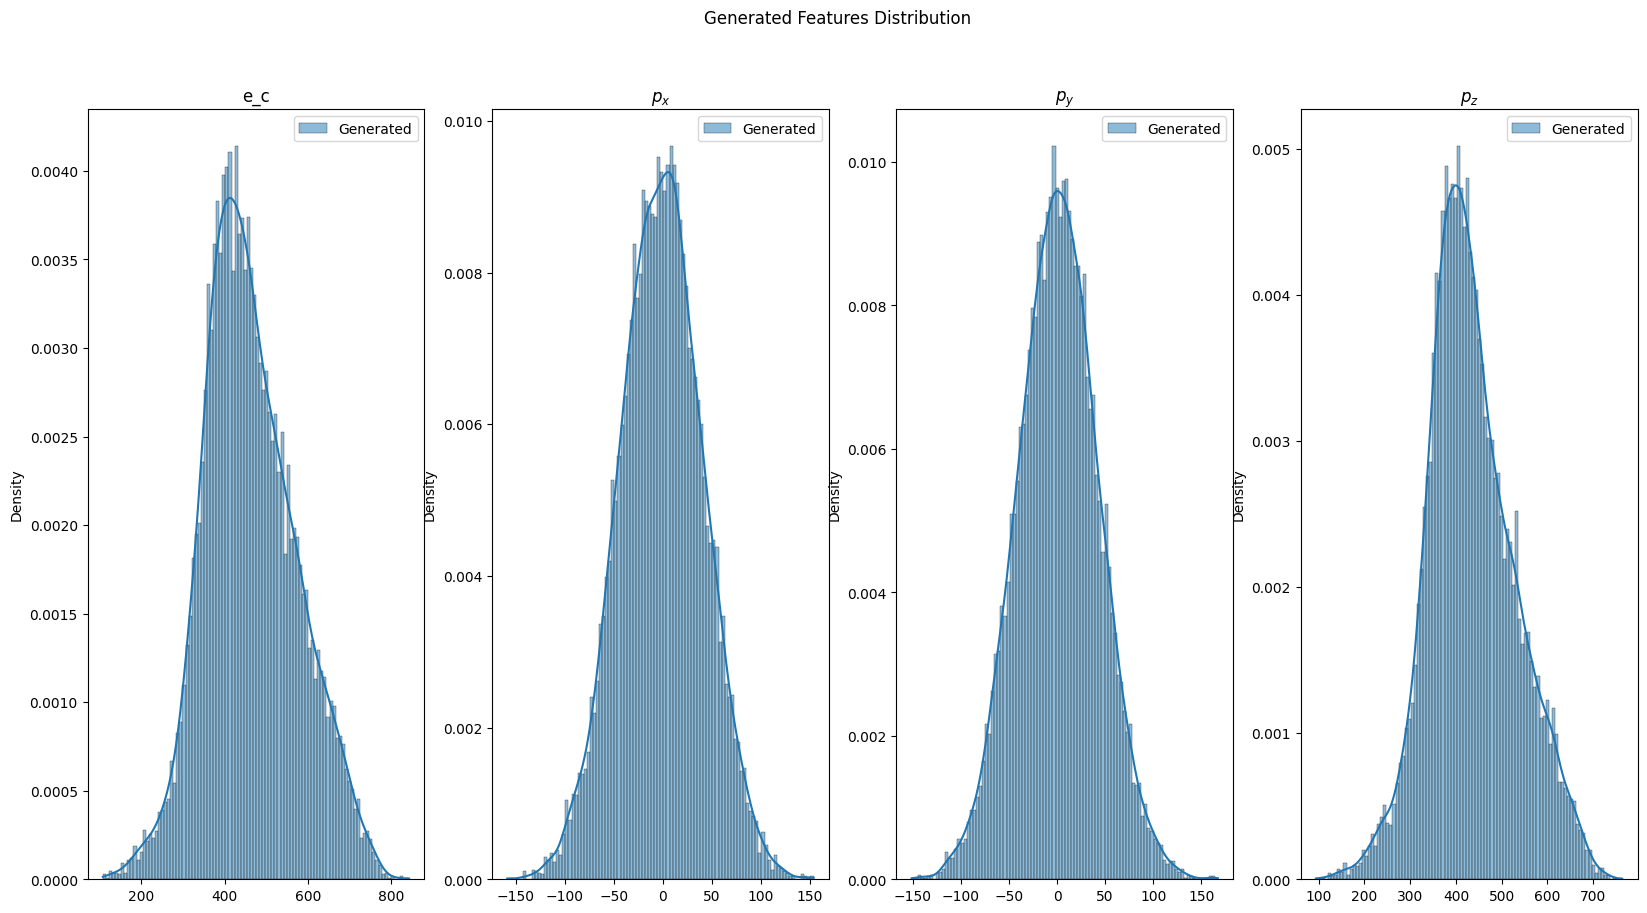

In [13]:
print(gen_features_cartesian.shape)

e_c = gen_features_cartesian[:, :, 0]
p_x = gen_features_cartesian[:, :, 1]
p_y = gen_features_cartesian[:, :, 2]
p_z = gen_features_cartesian[:, :, 3]

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features = [r"e_c", r"$p_x$", r"$p_y$", r"$p_z$"]
 
for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        gen_features_cartesian[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Generated Features Distribution")

In [14]:
gen_features_absolute = cartesian_to_EtaPhiPtE(gen_features_cartesian)
gen_features_absolute[:, :, 1] += np.pi

Text(0.5, 0.98, 'Generated Features Distribution')

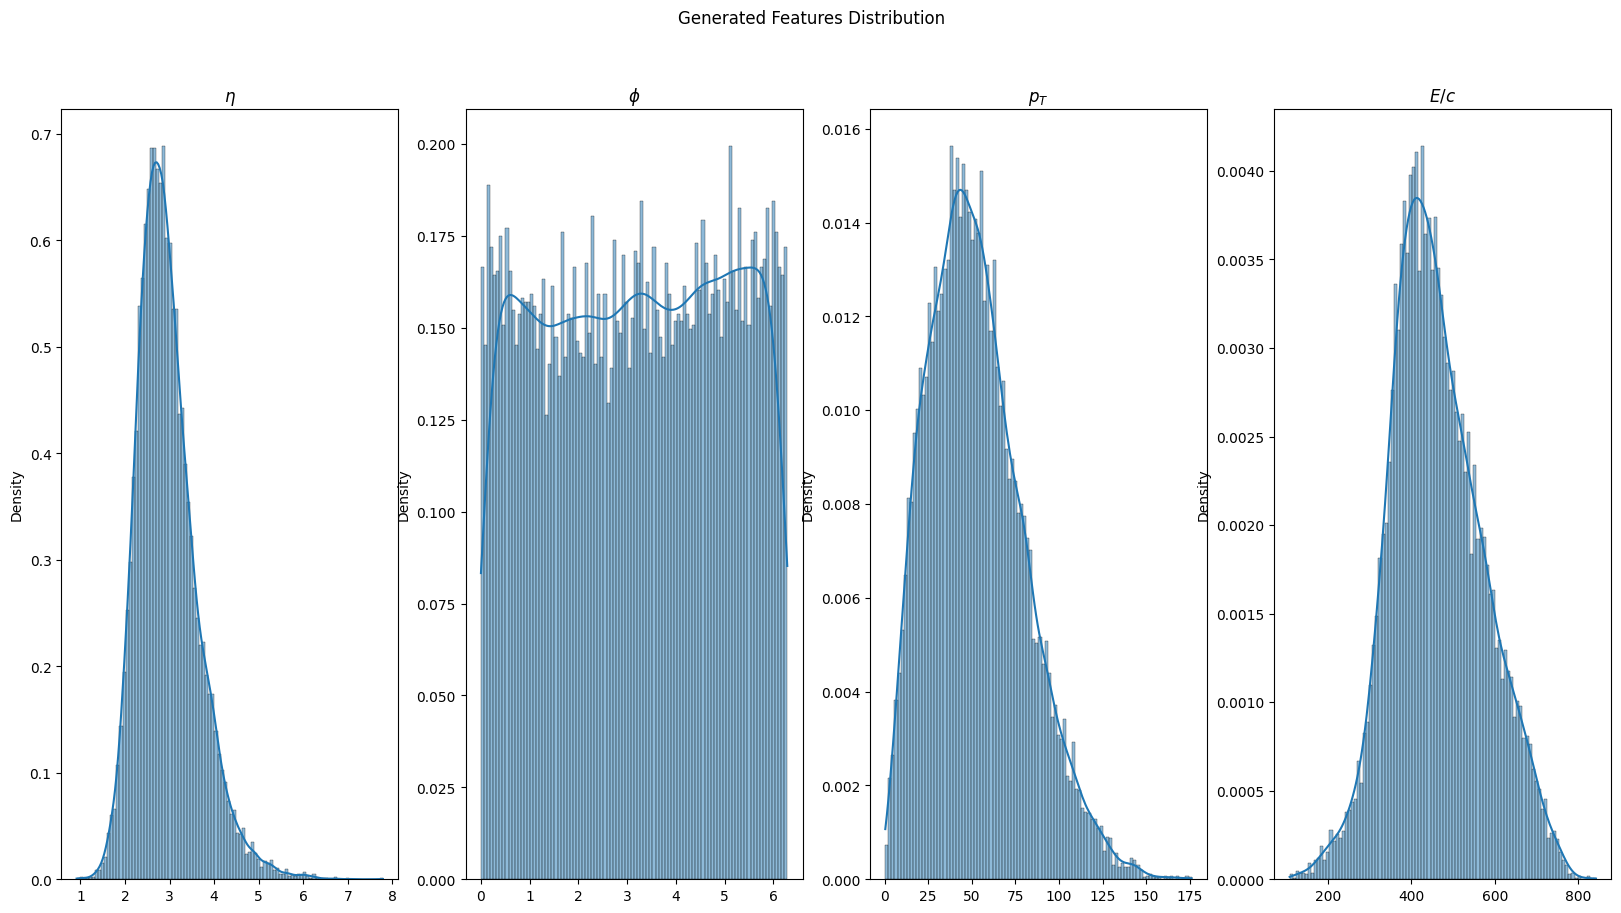

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features = [r"$\eta$", r"$\phi$", r"$p_T$", r"$E/c$"]

for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        gen_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    ax.set_title(feature)
plt.suptitle("Generated Features Distribution")

## Evaluate generated samples

### Plots

Text(0.5, 0.98, 'Generated vs Test Distribution (Polar)')

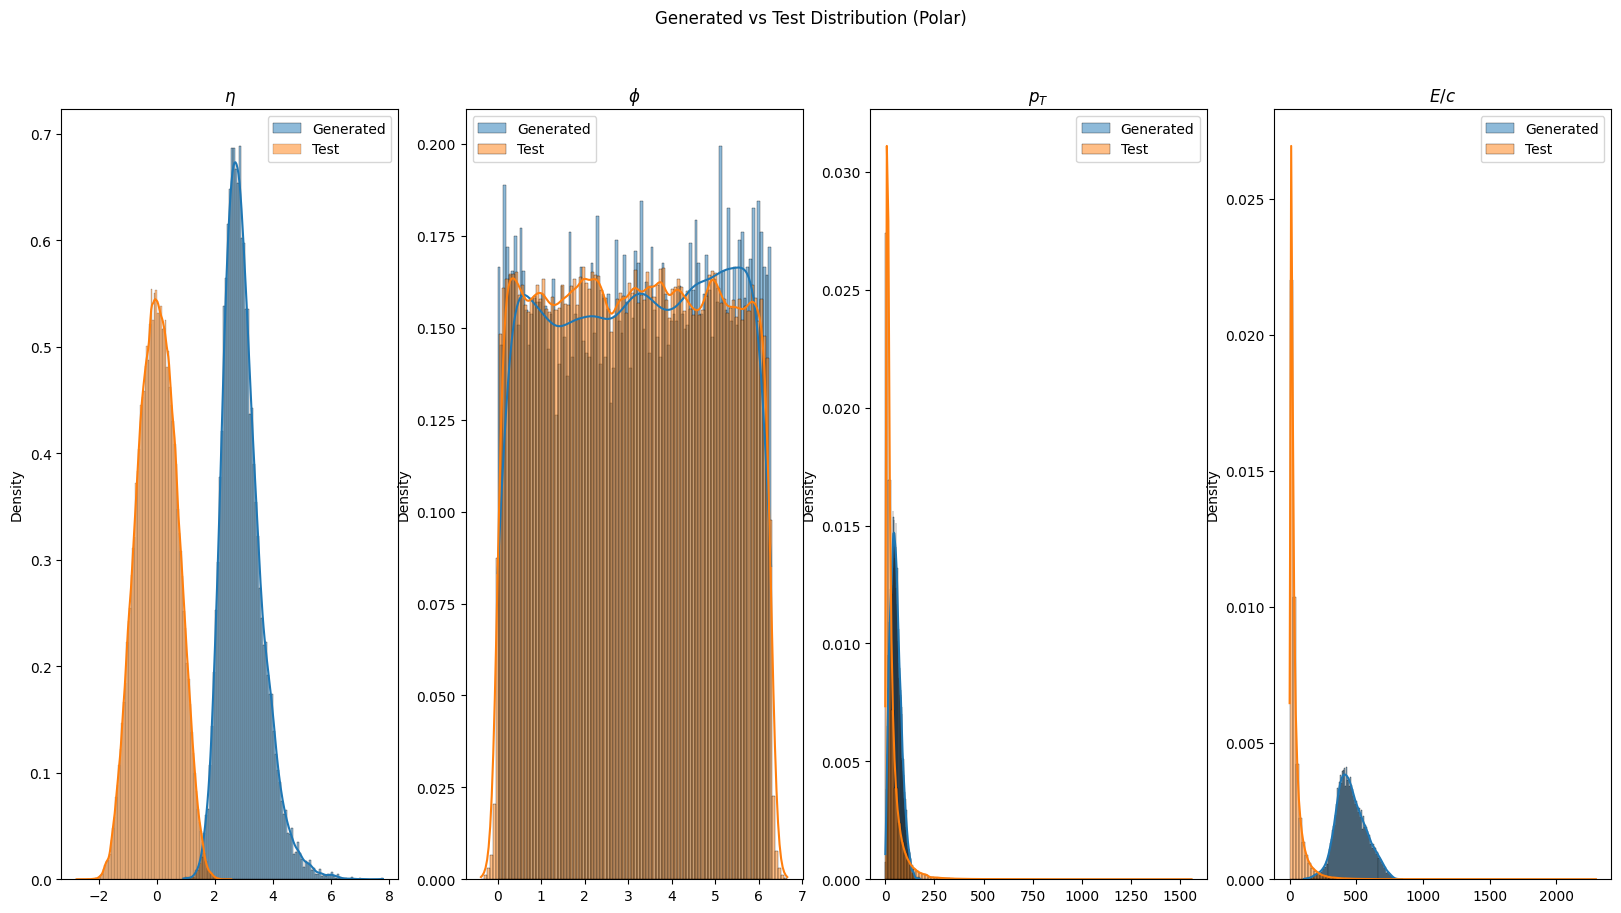

In [16]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
    
for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        gen_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    sns.histplot(
        test_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Test"
    )
    ax.set_title(feature)
    ax.legend()

plt.suptitle("Generated vs Test Distribution (Polar)")

Text(0.5, 0.98, 'Generated vs Test Distribution (Cartesian)')

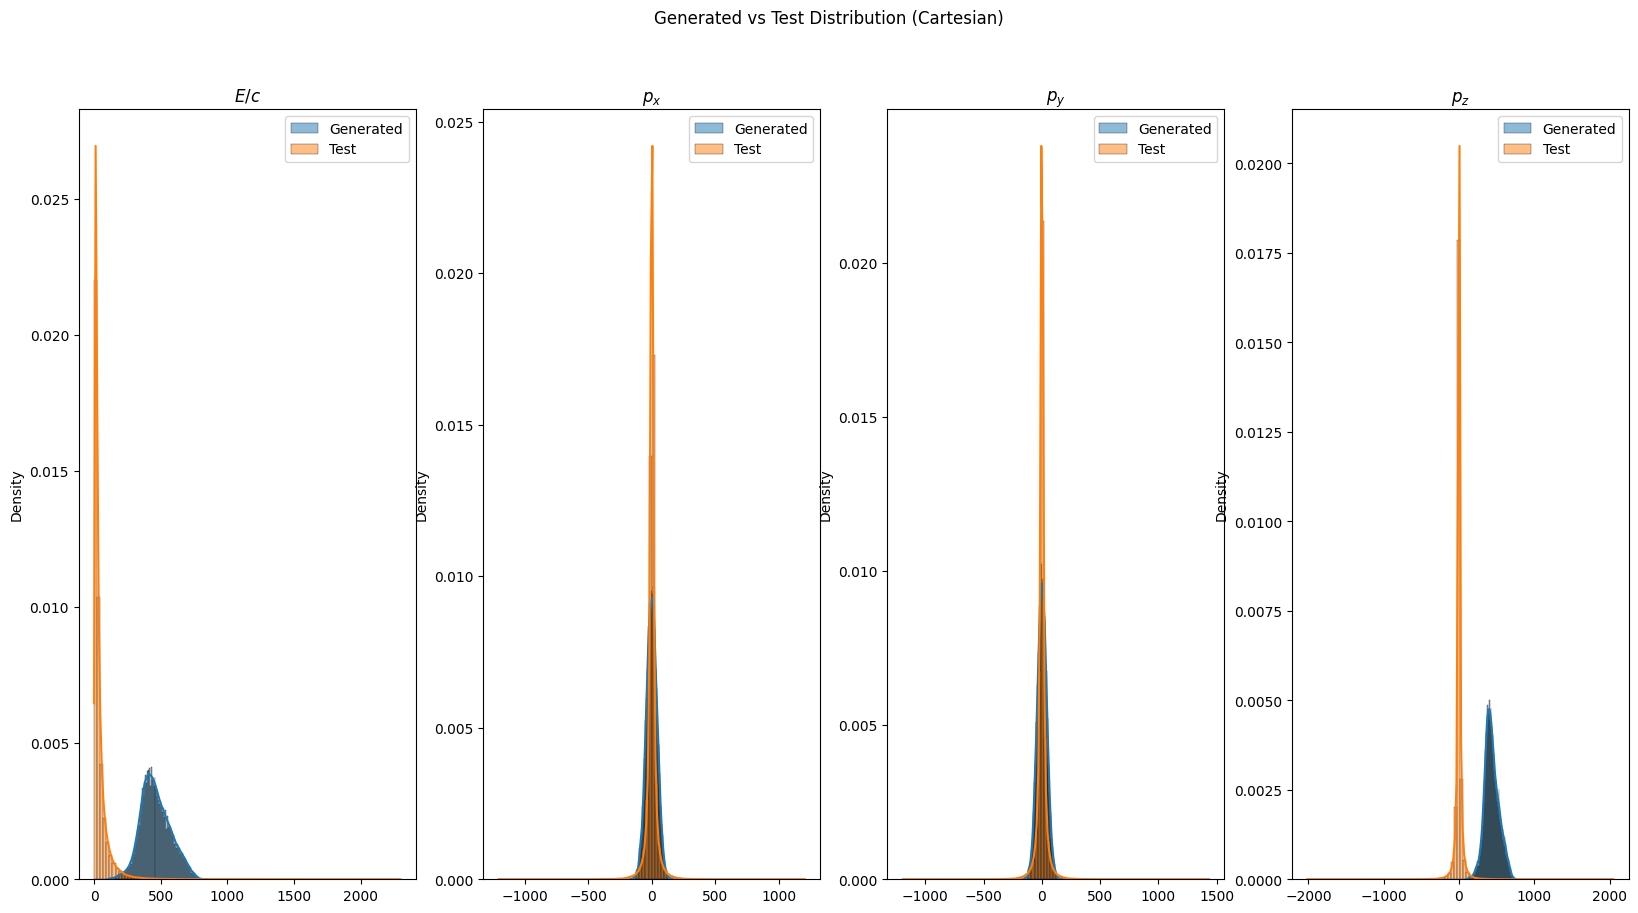

In [17]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features_cartesian = [r"$E/c$", r"$p_x$", r"$p_y$", r"$p_z$"]
for i, feature in enumerate(features_cartesian):
    ax = axs[i]
    sns.histplot(
        gen_features_cartesian[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    sns.histplot(
        test_features_cartesian[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Test"
    )
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Generated vs Test Distribution (Cartesian)")

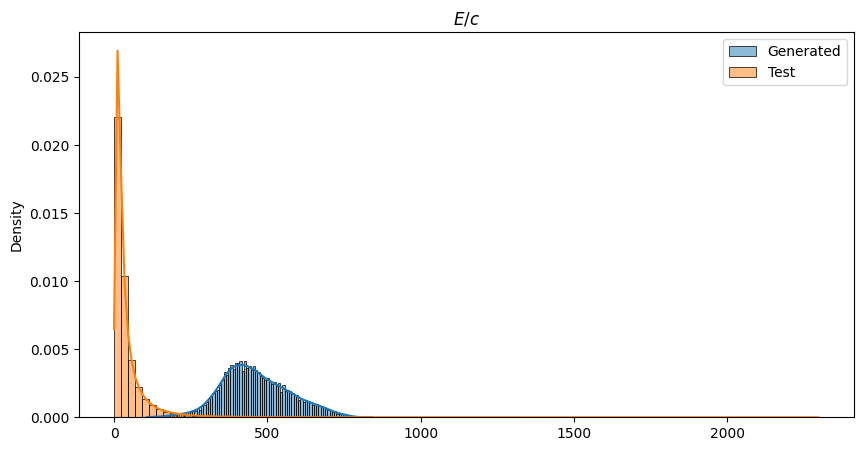

In [18]:
# Just plot e/c
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    gen_features_cartesian[:, :, 0].flatten().numpy(),
    bins=100,
    ax=ax,
    stat="density",
    kde=True,
    label="Generated"
)
sns.histplot(
    test_features_cartesian[:, :, 0].flatten().numpy(),
    bins=100,
    ax=ax,
    stat="density",
    kde=True,
    label="Test"
)
ax.set_title(r"$E/c$")
ax.legend()

### Metrics

In [19]:
import jetnet.evaluation as jetnet_eval
eval_info = {}

In [20]:
# Has to be in order [eta, phi, pt]. Drop e/c for MMD
eval_info["cov_mmd"] = jetnet_eval.cov_mmd(
    real_jets=test_features_absolute[:, :, :3],
    gen_jets=gen_features_absolute[:, :, :3]
)
eval_info["cov_mmd"]

Calculating cov and mmd over 10 batches: 100%|██████████| 10/10 [00:01<00:00,  6.39it/s]


(0.044, 2971.3403123885905)

In [21]:
NUM_PARTICLE_FEATURES = 4
eval_info["fpd"] = jetnet_eval.fpd(
    real_features=test_features_absolute.reshape((-1, NUM_PARTICLE_FEATURES)),
    gen_features=gen_features_absolute.reshape((-1, NUM_PARTICLE_FEATURES)),
    seed=RANDOM_SEED
)
eval_info["fpd"]

/var/folders/nf/5j1mvt3s2xxg28f4qcpqlhx40000gn/T/ipykernel_53957/3490047599.py:2: RuntimeWarning: Recommended number of samples for FPD estimation is 50,000
  eval_info["fpd"] = jetnet_eval.fpd(


(1.1778742183640918, 0.001235771824622561)

In [22]:
jets1 = gen_features_absolute
jets2 = test_features_absolute
eval_info["w1efp"] = jetnet_eval.w1efp(
    jets1=jets1,
    jets2=jets2,
)
eval_info["w1m"] = jetnet_eval.w1m(
    jets1=jets1,
    jets2=jets2,
)
eval_info["w1p"] = jetnet_eval.w1p(
    jets1=jets1,
    jets2=jets2,
)
eval_info["w1efp"], eval_info["w1m"], eval_info["w1p"]

/var/folders/nf/5j1mvt3s2xxg28f4qcpqlhx40000gn/T/ipykernel_53957/2257695816.py:3: RuntimeWarning: Recommended number of jets for W1 estimation is 50,000
  eval_info["w1efp"] = jetnet_eval.w1efp(
/var/folders/nf/5j1mvt3s2xxg28f4qcpqlhx40000gn/T/ipykernel_53957/2257695816.py:7: RuntimeWarning: Recommended number of jets for W1 estimation is 50,000
  eval_info["w1m"] = jetnet_eval.w1m(
/var/folders/nf/5j1mvt3s2xxg28f4qcpqlhx40000gn/T/ipykernel_53957/2257695816.py:11: RuntimeWarning: Recommended number of jets for W1 estimation is 50,000
  eval_info["w1p"] = jetnet_eval.w1p(


((array([7.00629540e+13, 6.77766623e+13, 6.83972383e+13, 4.91643373e+13,
         5.52372017e+13]),
  array([8.74015037e+10, 8.61697605e+10, 8.65696444e+10, 6.47958505e+10,
         7.03787241e+10])),
 (12746.118542836546, 16.45336017555293),
 (array([2.95386465e+00, 5.93848896e-02, 2.64613725e+01, 4.19342874e+02]),
  array([0.00378566, 0.00531475, 0.03106289, 0.25922671])))

In [ ]:
eval_info["fpnd_g"] = jetnet_eval.fpnd(
    jets=gen_features_absolute[:, :, :3],
    jet_type="g"
)
eval_info["fpnd_g"]

/var/folders/nf/5j1mvt3s2xxg28f4qcpqlhx40000gn/T/ipykernel_53957/2633837081.py:1: RuntimeWarning: Recommended number of jets for FPND calculation is 50000
  eval_info["fpnd_g"] = jetnet_eval.fpnd(


3182370478.266589

In [25]:
eval_info["fpnd_t"] = jetnet_eval.fpnd(
    jets=test_features_absolute[:, :, :3],
    jet_type="g"
)
eval_info["fpnd_t"]

Running ParticleNet:   0%|          | 0/3125 [00:00<?, ?it/s]

Running ParticleNet: 100%|██████████| 3125/3125 [02:20<00:00, 22.22it/s]


2345132080.5769944